# GSVD alignment angle on word embeddings (PT-BR vs English)

The same **gsvdlib** pipeline, no images anywhere: **A** holds MUSE-aligned
fastText embeddings (300d) of Portuguese words and **B** the embeddings of
their English translations. Because the MUSE vectors live in one shared
multilingual space, the GSVD frame tells us which directions of that space
are *shared* between the two languages and which are *language-specific* —
and theta(z) scores any embedding by how PT-like or EN-like it is.

Data: top-20k vectors of `wiki.multi.pt.vec` / `wiki.multi.en.vec` plus the
MUSE en-pt dictionary, cached by `_fetch_muse.py` (run it once first).

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from gsvdlib import (ArrayDataset, prepare_data, theta_angles,
                     metrics_from_angles, linear_cka,
                     get_angles_C, highlight_closest, get_most_similar_row_H)
from gsvdlib.plots import LineRenderer, plot_samples, plot_angles, \
    plot_angle_histogram, plot_posterior

data = np.load(Path.home() / ".gsvdlib" / "muse" / "muse_pt_en_top20000.npz")
pt_words, pt_X = list(data["pt_words"]), data["pt_X"].astype(float)
en_words, en_X = list(data["en_words"]), data["en_X"].astype(float)
print("PT:", pt_X.shape, " EN:", en_X.shape)

PT: (300, 20000)  EN: (300, 20000)


## 1. Paired vocabulary → an `ArrayDataset`

We keep translation pairs where both sides are in the top-20k vocabularies,
are alphabetic and distinct, then split words into train/test. The generic
`ArrayDataset` takes it from there — the rest of the notebook is exactly the
same code path used for MNIST and CIFAR-10.

In [2]:
pt_idx = {w: i for i, w in enumerate(pt_words)}
en_idx = {w: i for i, w in enumerate(en_words)}

pairs, seen_en, seen_pt = [], set(), set()
for en_w, pt_w in zip(data["dict_en"], data["dict_pt"]):
    en_w, pt_w = str(en_w), str(pt_w)
    if (en_w in en_idx and pt_w in pt_idx
            and en_w.isalpha() and pt_w.isalpha()
            and len(en_w) > 2 and len(pt_w) > 2
            and en_w != pt_w                      # drop identical cognates
            and en_w not in seen_en and pt_w not in seen_pt):
        pairs.append((en_w, pt_w))
        seen_en.add(en_w)
        seen_pt.add(pt_w)
print(len(pairs), "usable en-pt pairs")
print("examples:", pairs[100:106])

rng = np.random.default_rng(1234)
order = rng.permutation(len(pairs))
n_train = 1200
train_p, test_p = order[:n_train], order[n_train:n_train + 1000]

def block(idxs):
    en_sel = [pairs[i][0] for i in idxs]
    pt_sel = [pairs[i][1] for i in idxs]
    X = np.hstack([pt_X[:, [pt_idx[w] for w in pt_sel]],
                   en_X[:, [en_idx[w] for w in en_sel]]])
    labels = np.array(["pt"] * len(pt_sel) + ["en"] * len(en_sel))
    words = pt_sel + en_sel
    return X, labels, words

X_tr, y_tr, words_tr = block(train_p)
X_te, y_te, words_te = block(test_p)

ds = ArrayDataset(splits={"train": (X_tr, y_tr), "test": (X_te, y_te)},
                  names={"pt": "Portuguese", "en": "English"})

8331 usable en-pt pairs
examples: [('part', 'parte'), ('november', 'novembro'), ('players', 'jogadores'), ('list', 'lista'), ('following', 'seguindo'), ('february', 'fevereiro')]


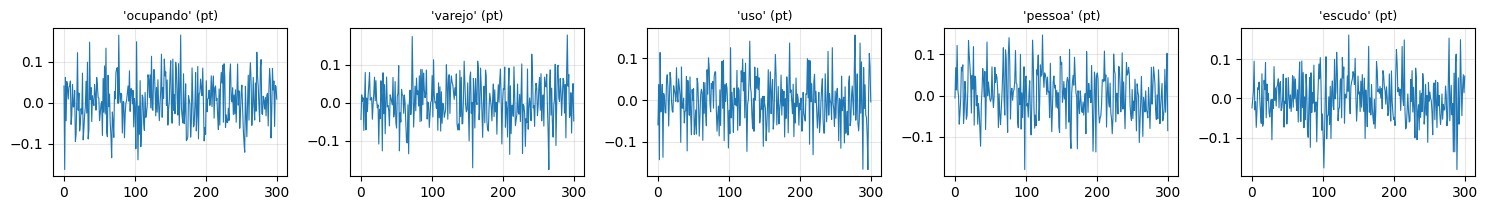

In [3]:
# "samples" are now word vectors: draw a few with the LineRenderer
show = [0, 1, 2, 3, 4]
fig, axes = plt.subplots(1, len(show), figsize=(3.0 * len(show), 2.2))
line = LineRenderer(lw=0.8)
for ax, j in zip(axes, show):
    line(ax, X_tr[:, j], title=f"'{words_tr[j]}' (pt)")
plt.tight_layout()

## 2. GSVD of A (Portuguese) vs B (English)

In [4]:
prep = prepare_data(ds, "pt", "en", n_A=900, n_B=800, seed=1234)
g = prep.gsvd

print("U:", g.U.shape, " V_til:", g.V_til.shape, " H:", g.H.shape)
print(f"blocks: bl={g.bl}  br={g.br}  wl={g.wl}  wr={g.wr}  r={g.r}")
errA = np.linalg.norm(prep.A.T - g.U @ g.C @ g.H)
errB = np.linalg.norm(prep.B.T - g.V_til @ g.S @ g.H)
print(f"||A' - U C H|| = {errA:.2e}   ||B' - V_til S H|| = {errB:.2e}")
print(f"linear CKA(pt, en) = {linear_cka(prep.A, prep.B):.4f}")

U: (900, 900)  V_til: (800, 800)  H: (300, 300)
blocks: bl=0  br=0  wl=600  wr=500  r=300
||A' - U C H|| = 8.61e-14   ||B' - V_til S H|| = 1.04e-13
linear CKA(pt, en) = 0.8512


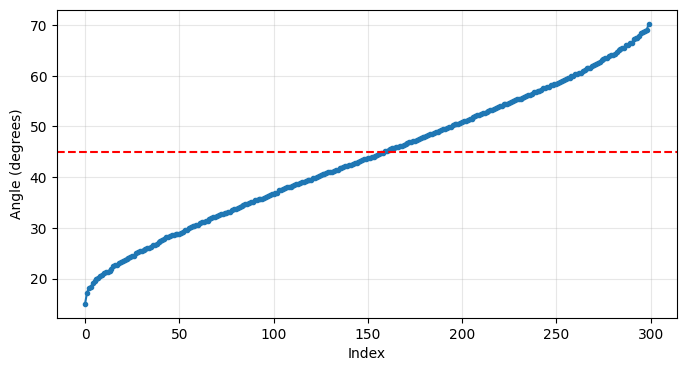

In [5]:
plot_angles(g.C, target_deg=45);

## 3. Interpreting the shared directions with words

Each shared row of `H` is a direction of the multilingual space. To read it,
we list the vocabulary words whose embeddings are most aligned with it
(`get_most_similar_row_H` against the full 20k PT and EN vocabularies) — the
embedding analogue of "plotting the H image" in the MNIST notebook.

In [6]:
angles = get_angles_C(g.C)
psc = int(highlight_closest(angles, 45, 1)[0])
picks = [g.bl, g.bl + 1, psc, g.bl + g.r - 2, g.bl + g.r - 1]

for i in picks:
    h = g.H[i, :]
    sim_pt = get_most_similar_row_H(h, pt_X.T)
    sim_en = get_most_similar_row_H(h, en_X.T)
    top_pt = [pt_words[j] for j in np.argsort(-np.abs(sim_pt))[:6]]
    top_en = [en_words[j] for j in np.argsort(-np.abs(sim_en))[:6]]
    print(f"H[{i}]  theta = {angles[i]:5.1f}\u00b0")
    print("   pt:", ", ".join(top_pt))
    print("   en:", ", ".join(top_en))

H[0]  theta =  15.1°
   pt: manoel, araújo, moreira, azevedo, pereira, fernandes
   en: joão, antónio, luís, oliveira, almeida, pedro


H[1]  theta =  17.2°
   pt: ambições, conquistas, pretensões, acções, possessões, atitudes
   en: mahmud, hamid, groom, punish, poly, sultan
H[159]  theta =  45.1°
   pt: tridimensional, pintura, dicionários, catálogo, coleção, tábuas
   en: catalogue, catalog, injuring, abstract, artworks, paintings
H[298]  theta =  69.1°
   pt: pauline, elisabeth, louise, diane, laura, hugo
   en: bees, sylvia, bucks, predators, audrey, capitals


H[299]  theta =  70.3°
   pt: richardson, dawson, jim, harold, bernie, tyler
   en: hugh, mortimer, reginald, bassett, richardson, lyons


## 4. Classifying held-out words by theta(z)

For each unseen embedding: is it better explained by the Portuguese frame or
the English one?

In [7]:
# theta for every held-out word, keeping the angle <-> word correspondence
Xte_pt = X_te[:, y_te == "pt"]
Xte_en = X_te[:, y_te == "en"]
words_te_pt = [w for w, y in zip(words_te, y_te) if y == "pt"]
words_te_en = [w for w, y in zip(words_te, y_te) if y == "en"]

angles_pt = theta_angles(Xte_pt, g.C, g.S, g.H)
angles_en = theta_angles(Xte_en, g.C, g.S, g.H)
print(f"PT: mean theta = {angles_pt.mean():.2f}\u00b0 (\u03c3={angles_pt.std():.2f})   "
      f"EN: mean theta = {angles_en.mean():.2f}\u00b0 (\u03c3={angles_en.std():.2f})")

PT: mean theta = 41.60° (σ=1.13)   EN: mean theta = 42.46° (σ=1.10)


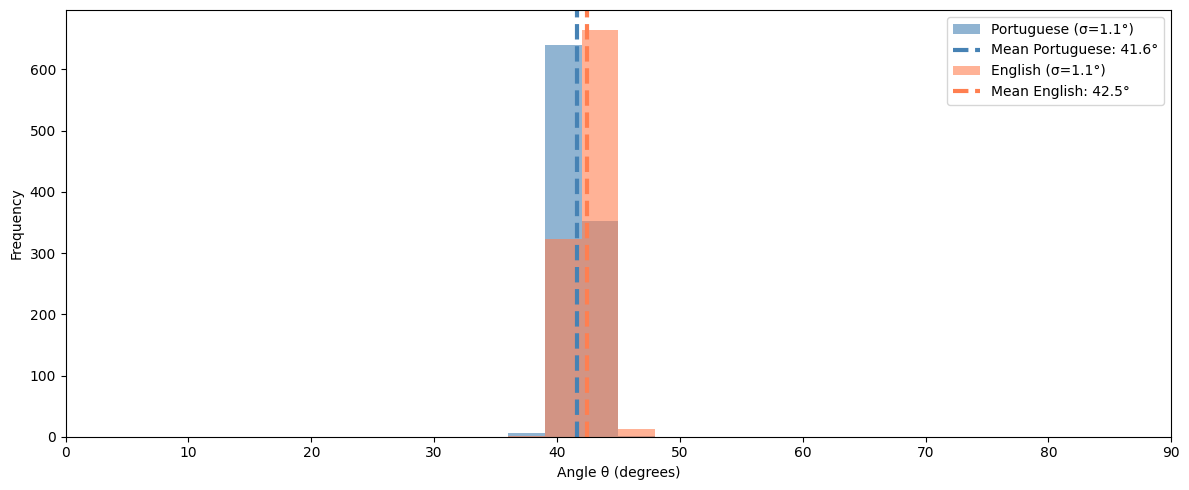

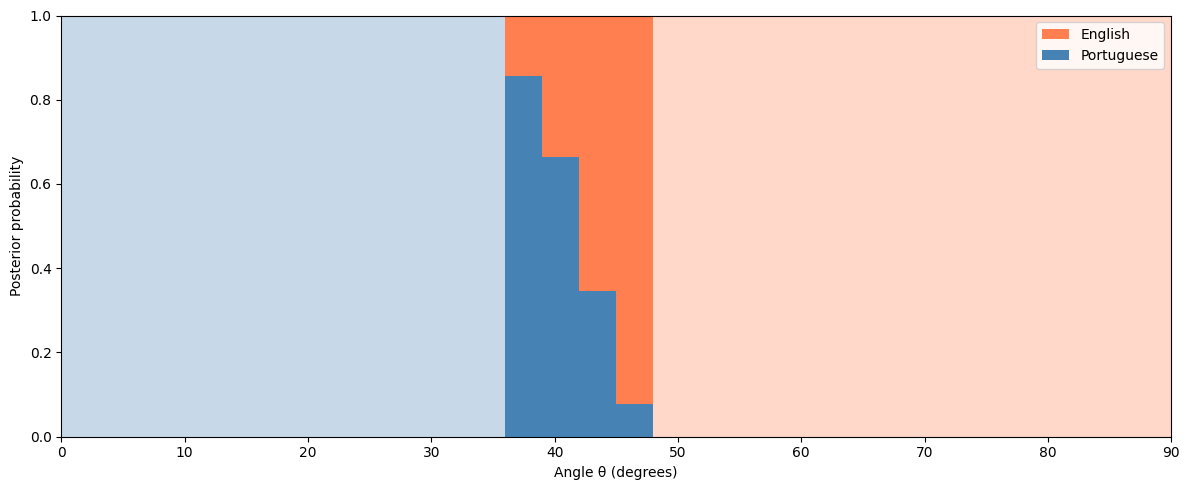

In [8]:
plot_angle_histogram(angles_pt, angles_en, "Portuguese", "English");
plot_posterior(angles_pt, angles_en, "Portuguese", "English");

In [9]:
m = metrics_from_angles(angles_pt, angles_en)
print(f"accuracy = {m['accuracy']:.4f}")
for side, name in (("A", "Portuguese"), ("B", "English")):
    print(f"{name:10s}  precision={m[f'precision_{side}']:.4f}"
          f"  recall={m[f'recall_{side}']:.4f}  f1={m[f'f1_{side}']:.4f}")

accuracy = 0.5055
Portuguese  precision=0.5028  recall=0.9990  f1=0.6689
English     precision=0.9231  recall=0.0120  f1=0.0237


In [10]:
# 45 deg is a geometric reference, not necessarily the best decision
# threshold: with aligned embeddings both distributions sit slightly below
# 45. Calibrating the threshold at the midpoint of the two class means:
thr = (angles_pt.mean() + angles_en.mean()) / 2
m2 = metrics_from_angles(angles_pt, angles_en, theta_threshold_deg=thr)
print(f"calibrated threshold = {thr:.2f} deg")
print(f"accuracy = {m2['accuracy']:.4f}")
for side, name in (("A", "Portuguese"), ("B", "English")):
    print(f"{name:10s}  precision={m2[f'precision_{side}']:.4f}"
          f"  recall={m2[f'recall_{side}']:.4f}  f1={m2[f'f1_{side}']:.4f}")

calibrated threshold = 42.03 deg
accuracy = 0.6610
Portuguese  precision=0.6626  recall=0.6560  f1=0.6593
English     precision=0.6594  recall=0.6660  f1=0.6627


In [11]:
# the most PT-like and most EN-like test words according to theta
i_pt = np.argsort(angles_pt)
i_en = np.argsort(angles_en)[::-1]
print("PT words with lowest theta (most Portuguese-like):")
print("  ", ", ".join(words_te_pt[j] for j in i_pt[:10]))
print("EN words with highest theta (most English-like):")
print("  ", ", ".join(words_te_en[j] for j in i_en[:10]))
print("PT words with highest theta (look 'English' to the frame):")
print("  ", ", ".join(words_te_pt[j] for j in i_pt[::-1][:10]))
print("EN words with lowest theta (look 'Portuguese' to the frame):")
print("  ", ", ".join(words_te_en[j] for j in i_en[::-1][:10]))

PT words with lowest theta (most Portuguese-like):
   hanôver, substituída, croácia, áustria, desapareceram, barra, governado, centímetros, indicador, esgotos
EN words with highest theta (most English-like):
   attempt, sweet, vincent, habit, seventy, forty, answer, stronghold, smith, christopher
PT words with highest theta (look 'English' to the frame):
   tenha, león, espetacular, realidade, pró, edição, suficiente, apóstolos, maior, carro
EN words with lowest theta (look 'Portuguese' to the frame):
   croatia, wikipedia, plumage, resides, residents, bavaria, persian, afghanistan, archbishop, sizes


## 5. Exploring the shared geometry

Beyond classification: *what do the shared and specific directions mean?*
Three probes:

1. a **spectrum** of H directions from θ=min to θ=max, each labeled by its
   nearest words in both vocabularies;
2. the **energy profile** of individual words across the θ-sorted frame —
   which words live in PT-specific, shared, or EN-specific directions;
3. **semantic relations as vectors** (`paris − frança` vs `paris − france`):
   relations that are invariant across the two languages should produce
   nearly the same offset vector and land in the shared band, while
   language-bound relations (morphology, diminutives) should not.

In [12]:
def v_pt(w):
    return pt_X[:, pt_idx[w]]

def v_en(w):
    return en_X[:, en_idx[w]]

def top_words(direction, k=5):
    sp = get_most_similar_row_H(direction, pt_X.T)
    se = get_most_similar_row_H(direction, en_X.T)
    tp = [pt_words[j] for j in np.argsort(-np.abs(sp))[:k]]
    te = [en_words[j] for j in np.argsort(-np.abs(se))[:k]]
    return tp, te

# --- 5.1 spectrum: 12 directions evenly spaced in theta -------------------
targets = np.linspace(angles.min(), angles.max(), 12)
spectrum = sorted({int(highlight_closest(angles, t, 1)[0]) for t in targets})
for i in spectrum:
    tp, te = top_words(g.H[i, :])
    print(f"theta = {angles[i]:5.1f}\u00b0  (H[{i}])")
    print(f"   pt: {', '.join(tp)}")
    print(f"   en: {', '.join(te)}")

theta =  15.1°  (H[0])
   pt: manoel, araújo, moreira, azevedo, pereira
   en: joão, antónio, luís, oliveira, almeida
theta =  20.0°  (H[6])
   pt: elaborados, estes, numerosos, actores, verdadeiros
   en: retired, resides, collectively, born, retiring
theta =  25.2°  (H[28])
   pt: artísticos, empresariais, concursos, coletivas, nacionais
   en: corpse, usernames, careers, organizers, finalists


theta =  30.1°  (H[56])
   pt: desenvolvimento, surgido, troféus, costas, desenvolvimentos
   en: development, developed, visionary, developments, innovation


theta =  35.1°  (H[88])
   pt: estrutural, bandidos, tesouros, reduzir, fogueira
   en: possessions, generalized, simplify, reactive, slaves
theta =  40.2°  (H[124])
   pt: hospedeiro, biologia, vertebrados, animais, estimação
   en: sister, beings, biology, zoology, vertebrates
theta =  45.2°  (H[160])
   pt: agir, revisar, decidir, imparcial, abriga
   en: erected, impartial, ignore, commemorating, recommend
theta =  50.2°  (H[195])
   pt: prisioneiro, predomina, diferencia, tipicamente, concentrada
   en: whereabouts, tends, expedition, differs, fugitive


theta =  55.2°  (H[228])
   pt: reduz, determinam, morou, equivalência, diferencial
   en: optimal, requires, ensures, enables, differentiation
theta =  60.3°  (H[260])
   pt: sobreviver, matar, morrendo, livrar, resistir
   en: safe, escaping, prepare, lethal, preventing
theta =  65.3°  (H[284])
   pt: insistir, citando, negar, observatore, justificar
   en: claims, allegation, insist, accuse, objected
theta =  70.3°  (H[299])
   pt: richardson, dawson, jim, harold, bernie
   en: hugh, mortimer, reginald, bassett, richardson


In [13]:
# --- 5.2 energy profile of words across the theta-sorted frame -----------
# v = H.T @ c  ->  c tells how much each direction contributes to the word.
Hinv_T = np.linalg.inv(g.H.T)

def energy_profile(v):
    c = Hinv_T @ v
    e = c**2
    return e / e.sum()

def band_fractions(v, lo=40.0, hi=50.0):
    e = energy_profile(v)
    return (e[angles < lo].sum(),
            e[(angles >= lo) & (angles <= hi)].sum(),
            e[angles > hi].sum())

probe = ["computador", "saudade", "feijoada", "internet", "futebol",
         "coração", "cidade", "praia"]
print(f"{'word':14s}  PT-side(<40\u00b0)  shared(40-50\u00b0)  EN-side(>50\u00b0)")
for w in probe:
    if w in pt_idx:
        a, b, c_ = band_fractions(v_pt(w))
        print(f"{w:14s}     {a:5.2f}          {b:5.2f}          {c_:5.2f}")
probe_en = ["computer", "software", "homesickness", "football", "heart",
            "city", "beach"]
print()
for w in probe_en:
    if w in en_idx:
        a, b, c_ = band_fractions(v_en(w))
        print(f"{w:14s}     {a:5.2f}          {b:5.2f}          {c_:5.2f}")

word            PT-side(<40°)  shared(40-50°)  EN-side(>50°)
computador          0.44           0.22           0.33
saudade             0.48           0.21           0.31
internet            0.48           0.19           0.33
futebol             0.57           0.16           0.27
coração             0.50           0.13           0.36
cidade              0.49           0.13           0.38
praia               0.47           0.21           0.32

computer            0.45           0.23           0.33
software            0.46           0.21           0.33
football            0.45           0.18           0.37
heart               0.44           0.16           0.40
city                0.49           0.14           0.37
beach               0.47           0.23           0.30


### 5.3 Semantic relations as vectors

For each relation we build the offset in each language, e.g.
`r_pt = v(paris) − v(frança)` and `r_en = v(paris) − v(france)`, and measure:

- **cos(r_pt, r_en)** — cross-language invariance of the relation itself;
- **θ(r_pt), θ(r_en)** — where the relation direction lives in the GSVD
  frame (PT side < 45° < EN side, shared band in the middle).

Baseline for calibration: the mean θ of ordinary words is ≈ 42°, and the
mean cosine between *unrelated* offset pairs is ≈ 0.

In [14]:
from gsvdlib import cosine_similarity

RELATIONS = {
    "capital-country": [
        ("paris", "frança", "paris", "france"),
        ("londres", "inglaterra", "london", "england"),
        ("roma", "itália", "rome", "italy"),
        ("berlim", "alemanha", "berlin", "germany"),
        ("lisboa", "portugal", "lisbon", "portugal"),
        ("moscou", "rússia", "moscow", "russia"),
        ("atenas", "grécia", "athens", "greece"),
        ("madrid", "espanha", "madrid", "spain"),
    ],
    "masculine-feminine": [
        ("rei", "rainha", "king", "queen"),
        ("homem", "mulher", "man", "woman"),
        ("pai", "mãe", "father", "mother"),
        ("ator", "atriz", "actor", "actress"),
        ("irmão", "irmã", "brother", "sister"),
        ("filho", "filha", "son", "daughter"),
    ],
    "singular-plural": [
        ("casa", "casas", "house", "houses"),
        ("livro", "livros", "book", "books"),
        ("cidade", "cidades", "city", "cities"),
        ("ano", "anos", "year", "years"),
        ("dia", "dias", "day", "days"),
        ("jogo", "jogos", "game", "games"),
    ],
    "antonyms": [
        ("grande", "pequeno", "big", "small"),
        ("novo", "velho", "new", "old"),
        ("alto", "baixo", "high", "low"),
        ("bom", "mau", "good", "bad"),
        ("guerra", "paz", "war", "peace"),
    ],
}

rows = []
for cat, quads in RELATIONS.items():
    for p1, p2, e1, e2 in quads:
        if not all([p1 in pt_idx, p2 in pt_idx, e1 in en_idx, e2 in en_idx]):
            print(f"  (skipping {p1}-{p2} / {e1}-{e2}: missing from top-20k vocab)")
            continue
        r_pt = v_pt(p1) - v_pt(p2)
        r_en = v_en(e1) - v_en(e2)
        cos = cosine_similarity(r_pt, r_en)
        th_pt = float(theta_angles(r_pt.reshape(-1, 1), g.C, g.S, g.H)[0])
        th_en = float(theta_angles(r_en.reshape(-1, 1), g.C, g.S, g.H)[0])
        rows.append((cat, f"{p1}-{p2} / {e1}-{e2}", cos, th_pt, th_en))

print(f"{'category':18s} {'relation':32s} {'cos':>6s} {'th_pt':>7s} {'th_en':>7s}")
for cat, name, cos, th_pt, th_en in rows:
    print(f"{cat:18s} {name:32s} {cos:6.2f} {th_pt:6.1f}\u00b0 {th_en:6.1f}\u00b0")

print()
print("mean cross-language cosine per category:")
for cat in RELATIONS:
    cs = [r[2] for r in rows if r[0] == cat]
    ts_pt = [r[3] for r in rows if r[0] == cat]
    ts_en = [r[4] for r in rows if r[0] == cat]
    if cs:
        print(f"  {cat:18s} cos = {np.mean(cs):.2f}   "
              f"theta_pt = {np.mean(ts_pt):.1f}\u00b0   theta_en = {np.mean(ts_en):.1f}\u00b0")

# random baseline: cosine between offsets of unrelated word pairs
rng_b = np.random.default_rng(0)
base = []
for _ in range(200):
    a, b, c_, d = rng_b.integers(0, len(pairs), 4)
    rb_pt = v_pt(pairs[a][1]) - v_pt(pairs[b][1])
    rb_en = v_en(pairs[c_][0]) - v_en(pairs[d][0])
    base.append(cosine_similarity(rb_pt, rb_en))
print(f"\nbaseline (unrelated offsets): cos = {np.mean(base):.2f} \u00b1 {np.std(base):.2f}")

category           relation                            cos   th_pt   th_en
capital-country    paris-frança / paris-france        0.71   43.5°   41.5°
capital-country    londres-inglaterra / london-england   0.61   44.7°   44.2°
capital-country    roma-itália / rome-italy           0.72   42.3°   41.9°
capital-country    berlim-alemanha / berlin-germany   0.65   43.2°   42.1°
capital-country    lisboa-portugal / lisbon-portugal   0.48   41.0°   40.9°
capital-country    moscou-rússia / moscow-russia      0.65   43.7°   44.0°
capital-country    atenas-grécia / athens-greece      0.67   42.8°   44.6°
capital-country    madrid-espanha / madrid-spain      0.69   41.1°   43.8°
masculine-feminine rei-rainha / king-queen            0.53   44.6°   42.7°
masculine-feminine homem-mulher / man-woman           0.58   42.2°   41.6°
masculine-feminine pai-mãe / father-mother            0.68   39.8°   42.3°
masculine-feminine ator-atriz / actor-actress         0.77   41.9°   41.9°
masculine-feminine ir

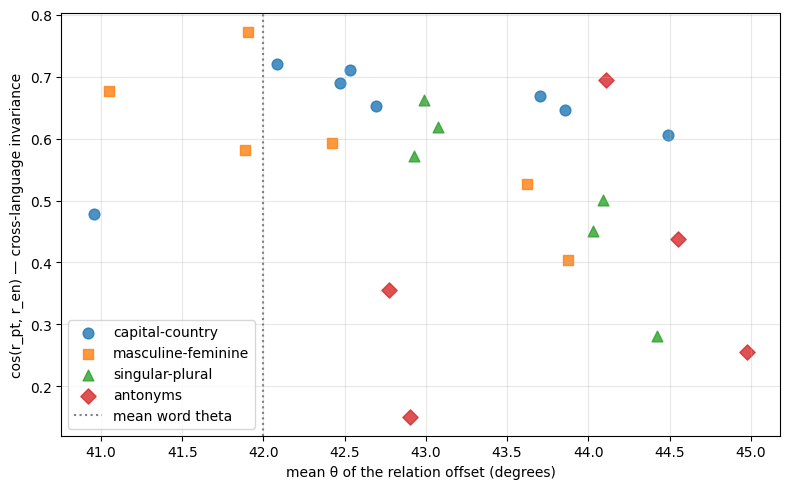

In [15]:
# scatter: invariance (cos) vs where the relation lives (mean theta)
fig, ax = plt.subplots(figsize=(8, 5))
markers = {"capital-country": "o", "masculine-feminine": "s",
           "singular-plural": "^", "antonyms": "D"}
for cat in RELATIONS:
    xs = [(r[3] + r[4]) / 2 for r in rows if r[0] == cat]
    ys = [r[2] for r in rows if r[0] == cat]
    ax.scatter(xs, ys, marker=markers[cat], s=60, label=cat, alpha=0.8)
ax.axvline(42.0, ls=":", color="gray", label="mean word theta")
ax.set_xlabel("mean θ of the relation offset (degrees)")
ax.set_ylabel("cos(r_pt, r_en) — cross-language invariance")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()

### 5.4 A relation that only exists in Portuguese: diminutives

`-inho/-inha` has no morphological counterpart in English. If the GSVD frame
is really separating language-specific structure, the diminutive offset
should (a) be coherent *within* PT (offsets of different words agree) and
(b) lean toward the PT side of the frame compared with ordinary words.

In [16]:
# Diminutives are rare in formal Wikipedia text, so this cell uses an
# extended PT vocabulary (top-100k, cached by the fetch script) just for
# this analysis.
big = np.load(Path.home() / ".gsvdlib" / "muse" / "muse_pt_top100k.npz")
big_words, big_X = list(map(str, big["words"])), big["X"].astype(float)
big_idx = {w: i for i, w in enumerate(big_words)}

def v_big(w):
    return big_X[:, big_idx[w]]

dims = [("casa", "casinha"), ("gato", "gatinho"), ("pouco", "pouquinho"),
        ("amigo", "amiguinho"), ("café", "cafezinho"), ("beijo", "beijinho"),
        ("pedaço", "pedacinho"), ("cidade", "cidadezinha"),
        ("irmã", "irmãzinha"), ("cavalo", "cavalinho"), ("bola", "bolinha"),
        ("carro", "carrinho"), ("barco", "barquinho"), ("igreja", "igrejinha"),
        ("fazenda", "fazendinha"), ("escola", "escolinha"),
        ("praça", "pracinha"), ("neto", "netinho"), ("irmão", "irmãozinho"),
        ("velho", "velhinho"), ("baixo", "baixinho"), ("bonito", "bonitinho")]
offs, kept = [], []
for w, wd in dims:
    if w in big_idx and wd in big_idx:
        offs.append(v_big(wd) - v_big(w))
        kept.append(f"{w}-{wd}")
offs = np.array(offs)
print(f"{len(kept)} diminutive pairs:", ", ".join(kept))

# (a) internal coherence: do different -inho offsets point the same way?
cos_mat = [cosine_similarity(offs[i], offs[j])
           for i in range(len(offs)) for j in range(i + 1, len(offs))]
print(f"internal coherence: mean pairwise cos = {np.mean(cos_mat):.2f}")
# baseline: offsets between unrelated PT words
rng_d = np.random.default_rng(1)
rand_off = [v_big(big_words[rng_d.integers(0, 20000)])
            - v_big(big_words[rng_d.integers(0, 20000)]) for _ in range(len(offs))]
cos_rand = [cosine_similarity(rand_off[i], rand_off[j])
            for i in range(len(rand_off)) for j in range(i + 1, len(rand_off))]
print(f"baseline (random offsets):  mean pairwise cos = {np.mean(cos_rand):.2f}")

# (b) where does the diminutive direction live in the GSVD frame?
th_dim = theta_angles(offs.T, g.C, g.S, g.H)
print(f"\ndiminutive offsets:  mean theta = {th_dim.mean():.2f}\u00b0 "
      f"(min {th_dim.min():.1f}\u00b0, max {th_dim.max():.1f}\u00b0)")
print(f"ordinary PT words:   mean theta = {angles_pt.mean():.2f}\u00b0")
print(f"ordinary EN words:   mean theta = {angles_en.mean():.2f}\u00b0")

# compare with the same statistic for the (shared) plural relation in PT
plur = [v_pt(b) - v_pt(a) for a, b, _, _ in RELATIONS["singular-plural"]
        if a in pt_idx and b in pt_idx]
th_plur = theta_angles(np.array(plur).T, g.C, g.S, g.H)
print(f"PT plural offsets:   mean theta = {th_plur.mean():.2f}\u00b0")

# and the mean gender offset, which exists in both languages
gen = [v_pt(b) - v_pt(a) for a, b, _, _ in RELATIONS["masculine-feminine"]
       if a in pt_idx and b in pt_idx]
th_gen = theta_angles(np.array(gen).T, g.C, g.S, g.H)
print(f"PT gender offsets:   mean theta = {th_gen.mean():.2f}\u00b0")

22 diminutive pairs: casa-casinha, gato-gatinho, pouco-pouquinho, amigo-amiguinho, café-cafezinho, beijo-beijinho, pedaço-pedacinho, cidade-cidadezinha, irmã-irmãzinha, cavalo-cavalinho, bola-bolinha, carro-carrinho, barco-barquinho, igreja-igrejinha, fazenda-fazendinha, escola-escolinha, praça-pracinha, neto-netinho, irmão-irmãozinho, velho-velhinho, baixo-baixinho, bonito-bonitinho
internal coherence: mean pairwise cos = 0.14
baseline (random offsets):  mean pairwise cos = 0.00

diminutive offsets:  mean theta = 43.40° (min 42.5°, max 45.0°)
ordinary PT words:   mean theta = 41.60°
ordinary EN words:   mean theta = 42.46°
PT plural offsets:   mean theta = 43.44°
PT gender offsets:   mean theta = 42.21°


## Interpretation

**Classification (section 4).** MUSE embeddings were *trained* to make the two
languages indistinguishable (CKA = 0.85, both theta distributions overlap
around 42\u00b0), so a single threshold separates them only weakly (66% after
calibration) - in sharp contrast with the MNIST pairs (CKA 0.1-0.7,
90-97%). The value of the frame here is diagnostic, not discriminative.

**The theta spectrum is semantically ordered (5.1).** Walking H from low to
high theta reads like a gradient of language specificity: Portuguese proper
names (15\u00b0), PT-inflected vocabulary (20-25\u00b0), then a wide bilingual band
where the two word lists are literal translations of each other -
*desenvolvimento/development* (30\u00b0), *biologia, vertebrados / biology,
vertebrates* (40\u00b0), *imparcial/impartial* (45\u00b0) - and finally English
proper names (70\u00b0). The frame is not splitting topics; it is splitting
*how language-bound* each direction is.

**Individual words spread across the whole frame (5.2).** Even
culture-specific words like *saudade* or *feijoada* put roughly half their
energy on the PT side and a fifth in the shared band - single words are not
concentrated objects in this frame; directions, not words, carry the
language signal.

**Semantic relations are ordered by invariance (5.3).** The cross-language
cosine between offset vectors reproduces the intuition exactly, far above
the unrelated-offset baseline of 0.00:

| relation | mean cos(r_pt, r_en) |
|---|---|
| capital-country (*paris - franca* vs *paris - france*) | 0.65 |
| masculine-feminine | 0.59 |
| singular-plural | 0.51 |
| antonyms | 0.38 |

World-knowledge relations transfer best; morphology transfers less; the
"antonym direction" is the least stable across languages. All relation
offsets sit slightly *closer to the shared band* (mean theta 43-44\u00b0) than
ordinary words do (41.6\u00b0 / 42.5\u00b0) - relations are more language-neutral
than the words they connect.

**Diminutives: a negative result worth keeping (5.4).** The PT-only
*-inho/-inha* offset has weak internal coherence (0.14 vs 0.00 baseline)
and its mean theta (43.4\u00b0) does **not** lean toward the PT side. In these
aligned Wikipedia vectors the diminutive is not a clean linear direction -
plausibly because formal text uses diminutives rarely and mostly
lexicalized. A cleaner test would need embeddings trained on informal
Brazilian text, where the morphology is productive.